## Preparations for Google Colab

In [8]:
# needed packages
#!pip install -q RDKit pyarrow>=13.0.0
#!pip install pandas==3.0.3
#!pip install lifelines

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Preparation

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.3 MB/s eta 0:00:00


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error, silhouette_score
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr, spearmanr
#from lifelines.utils import concordance_index
from sklearn.model_selection import GroupShuffleSplit, train_test_split
import pandas as pd
import pickle
import sys
import math
import random
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
from rdkit import Chem
from torch_geometric.data import Data
import sys
sys.path.append('/content/drive/MyDrive')
from gnn_models_utils import (
    DrugResponseDataset,
    make_loaders,
    smiles_to_graph,
    weighted_mse_loss,
    set_seed,
    GroundedCrossAttentionModel,
    GCNDrugEncoder,
    #GATDrugEncoder,
    #GINDrugEncoder
)

In [ ]:
df = pd.read_pickle("/content/drive/MyDrive/datasets/harmonized_data_2292026_rightSMILES.pkl")
print(f"Data set successfully loaded: {df.shape}")

Data set successfully loaded: (144082, 2024)


In [ ]:
#df.to_parquet("/content/drive/MyDrive/datasets/harmonized_data_2292026_rightSMILES.parquet")

## Check dataset

In [ ]:
import re
other_cols = [
    col for col in df.columns
    if not col.startswith('Bit_') and not re.match(r'.* \(\d+\)', col)
]

print(f"Columns found ({len(other_cols)}):")
for col in other_cols:
    print(col)

NameError: name 'df' is not defined

In [ ]:
# Check the sample for known active ingredients
test_drugs = ['Paclitaxel', 'Cisplatin', 'Doxorubicin', 'Gefitinib']
check_df = df[df['DRUG_NAME'].isin(test_drugs)][['DRUG_ID', 'DRUG_NAME', 'SMILES']].drop_duplicates()
print(check_df)

In [ ]:
print(df['CANCER_TYPE'].unique())

## Training data

In [ ]:
'''# training data group split in train val
target = 'LN_IC50'
pharmacophores = ['Donor', 'Acceptor', 'Aromatic', 'Hydrophobe', 'LumpedHydrophobe', 'PosIonizable', 'NegIonizable', 'ZnBinder']
mfp_cols = [col for col in df.columns if col.startswith('Bit_')]
X_genomic = df.filter(regex=r'.* \(.*\)').values.astype('float32')
X_chem = df[pharmacophores + mfp_cols]
y = df[target].values.astype('float32')

# split data into train and test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=6726)
idx_train_val, idx_test = next(gss_test.split(X_genomic, y, groups=df['DRUG_ID']))

# separate validation set from training set
groups_train_val = df['DRUG_ID'].iloc[idx_train_val]
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.11, random_state=42)
idx_train, idx_val = next(gss_val.split(X_genomic[idx_train_val], y[idx_train_val], groups=groups_train_val))

idx_train = idx_train_val[idx_train]
idx_val = idx_train_val[idx_val]

preprocessor = ColumnTransformer(
    transformers=[
        ('pharmacophore', StandardScaler(), pharmacophores),
        #('mfp', PCA(n_components=50, random_state=42), mfp_cols)
        ('mfp', 'passthrough', mfp_cols)
    ],
    remainder='drop'
)
gene_scaler = StandardScaler()

X_genomic_train = gene_scaler.fit_transform(X_genomic[idx_train])
X_chem_train = preprocessor.fit_transform(X_chem.iloc[idx_train])

X_genomic_val = gene_scaler.transform(X_genomic[idx_val])
X_chem_val = preprocessor.transform(X_chem.iloc[idx_val])

X_genomic_test = gene_scaler.transform(X_genomic[idx_test])
X_chem_test = preprocessor.transform(X_chem.iloc[idx_test])

# scale IC50 values
#scaler = StandardScaler()
y_train = y[idx_train]#scaler.fit_transform(y[idx_train].reshape(-1, 1)).flatten()
y_val = y[idx_val]#scaler.transform(y[idx_val].reshape(-1, 1)).flatten()
y_test = y[idx_test]#scaler.transform(y[idx_test].reshape(-1, 1)).flatten()'''

In [ ]:
'''def make_loaders(batch_size=128, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        DrugResponseDataset(X_genomic_train, X_chem_train, y_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        generator=g,
    )
    val_loader = DataLoader(
        DrugResponseDataset(X_genomic_val, X_chem_val, y_val),
        batch_size=batch_size,
        shuffle=False,
    )
    test_loader = DataLoader(
        DrugResponseDataset(X_genomic_test, X_chem_test, y_test),
        batch_size=batch_size,
        shuffle=False,
    )
    return train_loader, val_loader, test_loader

class DrugResponseDataset(Dataset):
    def __init__(self, X_gen, X_ch, labels):
        self.X_genomic = torch.tensor(X_gen, dtype=torch.float32)
        self.X_chem = torch.tensor(X_ch if isinstance(X_ch, np.ndarray) else X_ch.values, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_genomic[idx], self.X_chem[idx], self.y[idx]'''

## Different ways to create gene tokens

### Pairwise correlation, then hierarchical clustering, fixed amount of clusters!

In [12]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist

gene_feature_names = df.filter(regex=r'.* \(.*\)').columns.tolist()

# correlation matrix for genomic features
X_genomic = df.filter(regex=r'.* \(.*\)').values.astype('float32')
gene_corr = np.corrcoef(X_genomic.T)  # (978, 978)

# distance matrix and ward-linkage
dist_matrix = np.clip(1.0 - gene_corr, 0, 2)
np.fill_diagonal(dist_matrix, 0)
condensed_dist = pdist(dist_matrix)
linkage_matrix = linkage(condensed_dist, method='ward')

# cut into X clusters (tokens)
num_tokens = 32
gene_clusters = fcluster(linkage_matrix, t=num_tokens, criterion='maxclust') - 1

gene_token_indices = [np.where(gene_clusters == i)[0] for i in range(num_tokens)]

for i, indices in enumerate(gene_token_indices):
    print(f"Gene Token {i}: {len(indices)} genes assigned")

Gene Token 0: 46 genes assigned
Gene Token 1: 65 genes assigned
Gene Token 2: 13 genes assigned
Gene Token 3: 28 genes assigned
Gene Token 4: 18 genes assigned
Gene Token 5: 43 genes assigned
Gene Token 6: 38 genes assigned
Gene Token 7: 26 genes assigned
Gene Token 8: 48 genes assigned
Gene Token 9: 20 genes assigned
Gene Token 10: 40 genes assigned
Gene Token 11: 14 genes assigned
Gene Token 12: 11 genes assigned
Gene Token 13: 46 genes assigned
Gene Token 14: 48 genes assigned
Gene Token 15: 26 genes assigned
Gene Token 16: 25 genes assigned
Gene Token 17: 39 genes assigned
Gene Token 18: 21 genes assigned
Gene Token 19: 39 genes assigned
Gene Token 20: 36 genes assigned
Gene Token 21: 12 genes assigned
Gene Token 22: 11 genes assigned
Gene Token 23: 24 genes assigned
Gene Token 24: 34 genes assigned
Gene Token 25: 26 genes assigned
Gene Token 26: 31 genes assigned
Gene Token 27: 16 genes assigned
Gene Token 28: 40 genes assigned
Gene Token 29: 38 genes assigned
Gene Token 30: 31 ge

### Cancer type
Each gene is assigned to the cancer type token for which it exhibits the highest specific upregulation (maximum Z-score) compared to all other cancer types.

In [ ]:
gene_cols = df.filter(regex=r'.* \(.*\)').columns.tolist()
X_genes = df[gene_cols].values
cancer_types = df['CANCER_TYPE'].values
unique_cancer_types = df['CANCER_TYPE'].unique()

mean_expr = np.array([X_genes[cancer_types == ct].mean(axis=0) for ct in unique_cancer_types])
mean_expr_z = (mean_expr - mean_expr.mean(axis=0)) / (mean_expr.std(axis=0) + 1e-8)
gene_assignments = np.argmax(mean_expr_z, axis=0)

gene_token_indices = []
active_labels = []

for ct_idx, ct_name in enumerate(unique_cancer_types):
    idx = np.where(gene_assignments == ct_idx)[0]
    if len(idx) > 0:
        gene_token_indices.append(idx)
        active_labels.append(ct_name)
        print(f"Token {len(gene_token_indices)-1} ({ct_name}): {len(idx)} genes")

### WGCNA

In [ ]:
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# pearson correlation
corr_matrix = np.corrcoef(X_genomic.T)

# Soft Thresholding (Create Adjacency Matrix)
# beta=6 is the standard bioinformatics value, to suppress weak noise and highlight strong signaling pathways.
beta = 6
adj_matrix = np.abs(corr_matrix) ** beta

# Calculate the Topological Overlap Measure (TOM)
# Matrix multiplication identifies the shared neighborhoods (signal pathways)
l_matrix = np.dot(adj_matrix, adj_matrix)

# Sum of connection strengths per gene (Connectivity)
k = np.sum(adj_matrix, axis=1)
k_min_matrix = np.minimum.outer(k, k)

# WGCNA TOM Formula
tom_matrix = (l_matrix + adj_matrix) / (k_min_matrix + 1.0 - adj_matrix)
np.fill_diagonal(tom_matrix, 1.0)

# Convert to a dissimilarity matrix
dist_matrix = 1.0 - tom_matrix
# Handle rounding errors and set the diagonal to 0
dist_matrix = np.clip(dist_matrix, 0.0, 1.0)
np.fill_diagonal(dist_matrix, 0.0)

# Hierarchical Clustering
condensed_dist = squareform(dist_matrix, checks=False)
Z = linkage(condensed_dist, method='average')

candidate_k = range(2, 51)
scores = []
for k in candidate_k:
    labels = fcluster(Z, t=k, criterion='maxclust') - 1
    # Silhouette score based on the WGCNA distance matrix
    score = silhouette_score(dist_matrix, labels, metric='precomputed')
    scores.append(score)

optimal_k = candidate_k[np.argmax(scores)]
print(f"Optimal number of tokens found: {optimal_k} (Silhouette Score: {max(scores):.4f})")

gene_clusters = fcluster(Z, t=optimal_k, criterion='maxclust') - 1
gene_token_indices = [np.where(gene_clusters == i)[0] for i in range(optimal_k)]

for i, indices in enumerate(gene_token_indices):
    print(f"Gene Token {i} (WGCNA module): {len(indices)} genes assigned")

## Configuration and training for tabular fingerprints (drugs)

First creation of drug tokens

In [ ]:
import numpy as np
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist

# Select chemical columns
chem_cols = pharmacophores + mfp_cols

# Extract unique drug feature matrix
unique_drugs_df = df.drop_duplicates(subset=['DRUG_ID'])[chem_cols]
chem_values = unique_drugs_df.values.astype(np.float64)  # shape: (n_drugs, 1032)

# Compute Pearson correlation with variance check
# Identify constant columns (zero variance)
std_devs = np.std(chem_values, axis=0)
valid_mask = std_devs > 1e-8

# Compute correlation matrix
chem_corr = np.zeros((len(chem_cols), len(chem_cols)), dtype=np.float64)

# Correlate non-constant features
chem_corr_valid = np.corrcoef(chem_values[:, valid_mask].T)

# Place valid correlations into full matrix
valid_indices = np.where(valid_mask)[0]
for i_idx, i in enumerate(valid_indices):
    for j_idx, j in enumerate(valid_indices):
        chem_corr[i, j] = chem_corr_valid[i_idx, j_idx]

# Convert correlation to distance: dist = 1 - r
dist_matrix_chem = 1.0 - chem_corr

# Handle any remaining NaN/Inf values by setting distance to 1.0 (uncorrelated)
dist_matrix_chem = np.nan_to_num(dist_matrix_chem, nan=1.0, posinf=1.0, neginf=1.0)
dist_matrix_chem = np.clip(dist_matrix_chem, 0.0, 2.0)
np.fill_diagonal(dist_matrix_chem, 0.0)

# Hierarchical clustering on condensed distance matrix
condensed_dist = pdist(dist_matrix_chem)
linkage_chem = linkage(condensed_dist, method='ward')

# Extract cluster labels for X tokens
num_drug_tokens = 32
chem_cluster_labels = fcluster(linkage_chem, t=num_drug_tokens, criterion='maxclust') - 1

# Form index arrays for each token
chem_token_indices = [
    np.where(chem_cluster_labels == i)[0] for i in range(num_drug_tokens)
]

for i, idx in enumerate(chem_token_indices):
    print(f"Drug Token {i}: {len(idx)} features assigned")

In [ ]:
from sklearn.preprocessing import MinMaxScaler
target = 'LN_IC50'
pharmacophores = ['Donor', 'Acceptor', 'Aromatic', 'Hydrophobe', 'LumpedHydrophobe',
                   'PosIonizable', 'NegIonizable', 'ZnBinder']
mfp_cols = [col for col in df.columns if col.startswith('Bit_')]

X_genomic_raw = df.filter(regex=r'.* \(.*\)').values.astype('float32')
X_chem_raw = df[pharmacophores + mfp_cols]
y_raw = df[target].values.astype('float32')
drug_groups = df['DRUG_ID'].values

seeds = [42, 101, 1337, 9999]
#seeds = [101]
hidden_dim = 64
dropout = 0.1
lr = 2e-4
weight_decay = 1e-3
epochs = 25
patience = 5
batch_size = 512

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Used device:", device)

# ==========================================
# Run data splits and scaling ONCE
# ==========================================
print("\nPrepare datasets and GPU tensors...")
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=18092026)
idx_train_val, idx_test = next(gss_test.split(X_genomic_raw, y_raw, groups=drug_groups))

groups_train_val = drug_groups[idx_train_val]
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.11, random_state=18092026)
idx_tr_rel, idx_val_rel = next(
    gss_val.split(X_genomic_raw[idx_train_val], y_raw[idx_train_val], groups=groups_train_val)
)
idx_train = idx_train_val[idx_tr_rel]
idx_val = idx_train_val[idx_val_rel]

# Feature-Skalierung
preprocessor = ColumnTransformer(
    transformers=[
        ('pharmacophore', StandardScaler(), pharmacophores),
        ('mfp', 'passthrough', mfp_cols)
    ],
    remainder='drop'
)
gene_scaler = StandardScaler()

X_gen_train = gene_scaler.fit_transform(X_genomic_raw[idx_train])
X_chem_train = preprocessor.fit_transform(X_chem_raw.iloc[idx_train])

X_gen_val = gene_scaler.transform(X_genomic_raw[idx_val])
X_chem_val = preprocessor.transform(X_chem_raw.iloc[idx_val])

X_gen_test = gene_scaler.transform(X_genomic_raw[idx_test])
X_chem_test = preprocessor.transform(X_chem_raw.iloc[idx_test])

# Target scaling to [0.05, 0.95] for a stable sigmoid output
y_scaler = MinMaxScaler(feature_range=(0.05, 0.95))
y_train_scaled = y_scaler.fit_transform(y_raw[idx_train].reshape(-1, 1)).flatten().astype('float32')
y_val_scaled   = y_scaler.transform(y_raw[idx_val].reshape(-1, 1)).flatten().astype('float32')
y_test_orig    = y_raw[idx_test]

# Load data sets completely into VRAM (no more CPU transfers in the loop!)
t_X_gen_train  = torch.as_tensor(X_gen_train, dtype=torch.float32, device=device)
t_X_chem_train = torch.as_tensor(X_chem_train, dtype=torch.float32, device=device)
t_y_train      = torch.as_tensor(y_train_scaled, dtype=torch.float32, device=device)

t_X_gen_val    = torch.as_tensor(X_gen_val, dtype=torch.float32, device=device)
t_X_chem_val   = torch.as_tensor(X_chem_val, dtype=torch.float32, device=device)
t_y_val        = torch.as_tensor(y_val_scaled, dtype=torch.float32, device=device)

t_X_gen_test   = torch.as_tensor(X_gen_test, dtype=torch.float32, device=device)
t_X_chem_test  = torch.as_tensor(X_chem_test, dtype=torch.float32, device=device)

n_train = t_X_gen_train.size(0)
n_val   = t_X_gen_val.size(0)
n_test  = t_X_gen_test.size(0)
print(f"Daten im GPU-RAM: Train={n_train}, Val={n_val}, Test={n_test}")

# ==========================================
# Seed Evaluation
# ==========================================
seed_results = []
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

for run_idx, seed in enumerate(seeds):
    print(f"\n==========================================")
    print(f"Seed {run_idx + 1}/{len(seeds)} (Seed-value: {seed})")
    print(f"==========================================")

    set_seed(seed)

    model = GroundedCrossAttentionModel(
        gene_token_indices=gene_token_indices,
        chem_token_indices=chem_token_indices,
        hidden_dim=hidden_dim,
        num_heads=4,
        dropout=dropout
    ).to(device)

    criterion = nn.MSELoss()
    #criterion = weighted_mse_loss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=patience)

    best_val_loss = float("inf")
    best_epoch = -1
    model_checkpoint_path = f"best_model_seed_{seed}.pt"

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n_train, device=device)
        train_loss = 0.0

        for i in range(0, n_train, batch_size):
            idx_batch = permutation[i:i + batch_size]
            b_genes = t_X_gen_train[idx_batch]
            b_chem  = t_X_chem_train[idx_batch]
            b_y     = t_y_train[idx_batch]

            optimizer.zero_grad(set_to_none=True)

            # Mixed Precision Forward Pass
            with torch.amp.autocast("cuda"):
                preds = model(b_genes, b_chem)
                loss = weighted_mse_loss(preds, b_y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * b_genes.size(0)

        # Fast Validation on the GPU
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for i in range(0, n_val, batch_size):
                b_genes = t_X_gen_val[i:i + batch_size]
                b_chem  = t_X_chem_val[i:i + batch_size]
                b_y     = t_y_val[i:i + batch_size]

                with torch.amp.autocast(device_type="cuda"):
                    preds = model(b_genes, b_chem)
                    loss = weighted_mse_loss(preds, b_y)
                val_loss += loss.item() * b_genes.size(0)

        mean_val_loss = val_loss / n_val
        scheduler.step(mean_val_loss)

        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_epoch = epoch + 1
            torch.save(model.state_dict(), model_checkpoint_path)

    # Test Evaluation (with original scale for metrics)
    model.load_state_dict(torch.load(model_checkpoint_path, weights_only=True))
    model.eval()

    test_preds_list = []
    with torch.no_grad():
        for i in range(0, n_test, batch_size):
            b_genes = t_X_gen_test[i:i + batch_size]
            b_chem  = t_X_chem_test[i:i + batch_size]
            with torch.amp.autocast(device_type="cuda"):
                preds = model(b_genes, b_chem, save_attention=(i==0))
            test_preds_list.append(preds.cpu())

    # Merging and rescaling scaled predictions
    test_preds_scaled = torch.cat(test_preds_list).numpy()
    test_preds_orig = y_scaler.inverse_transform(test_preds_scaled.reshape(-1, 1)).flatten()

    test_rmse = root_mean_squared_error(y_test_orig, test_preds_orig)
    test_r2 = r2_score(y_test_orig, test_preds_orig)
    test_mae = mean_absolute_error(y_test_orig, test_preds_orig)
    test_pearson_corr, p_value_pearson = pearsonr(y_test_orig, test_preds_orig)
    test_spearman_corr, p_value_spearman = spearmanr(y_test_orig, test_preds_orig)
    #test_c_index = concordance_index(y_test_orig, test_preds_orig)

    print(f"--> Result Seed {seed}: Best Epoch: {best_epoch:02d} | Val Loss: {best_val_loss:.4f} | Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")

    seed_results.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "val_loss": best_val_loss,
        "test_rmse": test_rmse,
        "test_r2": test_r2,
        "test_mae": test_mae,
        "test_pearson_corr": test_pearson_corr,
        "test_spearman_corr": test_spearman_corr#,
        #"test_c_index": test_c_index
    })

df_results = pd.DataFrame(seed_results)
print("\n" + "="*50)
print("Analysis of all seeds")
print("="*50)
print(df_results.to_string(index=False))
print("\n--- Aggregated metrics (mean ± std) ---")
print(f"Test RMSE: {df_results['test_rmse'].mean():.4f} ± {df_results['test_rmse'].std():.4f}")
print(f"Test R²:   {df_results['test_r2'].mean():.4f} ± {df_results['test_r2'].std():.4f}")
# Spearman does not measure absolute accuracy, but rather how well the order of the predictions matches reality.
# Spearman penalizes it somewhat more severely when an active ingredient that should
# actually be in first place slips to the very bottom of the list (e.g., 100th place) than the C-index would.
print(f"Test Spearman coefficient: {df_results['test_spearman_corr'].mean():.4f} ± {df_results['test_spearman_corr'].std():.4f}")
# Pearson correlation measures the linear relationship between your predictions and the true values (from -1 to +1).
print(f"Test Pearson coefficient: {df_results['test_pearson_corr'].mean():.4f} ± {df_results['test_pearson_corr'].std():.4f}")
# CI indicates the probability that, given two random samples, the model will correctly predict which of the two reacts more sensitively.
# Specifically, a C-index of 0.70 means this: If I select any two drug-cell line
# pairs from the test set, my model correctly predicts 70% of the time which of the two pairs has the lower Z-score.
# good to understand for biologists or doctors
#print(f"Concordance index: {df_results['test_c_index'].mean():.4f} ± {df_results['test_c_index'].std():.4f}")
# more robust than RMSE
print(f"Test mean absolute error: {df_results['test_mae'].mean():.4f} ± {df_results['test_mae'].std():.4f}")
print("\n" + "="*50 + "\n")

## Configuration for graph representations (drugs)

In [23]:
import importlib
import gnn_models_utils

# Forces the file to be re-read from memory
importlib.reload(gnn_models_utils)

from gnn_models_utils import GroundedCrossAttentionModel

Optional: Automatically save graph structures

In [15]:
import os
import torch
from gnn_models_utils import smiles_to_graph

# Path to your cache file on Google Drive
cache_path = '/content/drive/MyDrive/processed_graphs_cache.pt'

if os.path.exists(cache_path):
    print("Load cached graphs from Google Drive...")
    # Loads the completed list into RAM in just a few seconds
    all_graphs = torch.load(cache_path)
else:
    print("Cache not found. Rebuild graph...")
    all_graphs = [smiles_to_graph(smiles) for smiles in df["SMILES"]]
    torch.save(all_graphs, cache_path)
    print(f"Graphs successfully cached at: {cache_path}")

Cache not found. Rebuild graph...
Graphs successfully cached at: /content/drive/MyDrive/processed_graphs_cache.pt


In [42]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import GroupShuffleSplit
from torch_geometric.loader import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np

target = 'LN_IC50'
smiles_raw = df['SMILES'].values
X_genomic_raw = df.filter(regex=r'.* \(.*\)').values.astype('float32')
y_raw = df[target].values.astype('float32')
drug_groups = df['DRUG_ID'].values

seeds = [42, 101, 1337, 9999]
#seeds = [101]
hidden_dim = 64
dropout = 0.15
lr = 2e-4
weight_decay = 1e-3
epochs = 25
patience = 5
batch_size = 512
gnn_type="GIN"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Used device:", device)
# ==========================================
# Run data splits and scaling ONCE
# ==========================================
print("\nPrepare datasets and splits...")
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=18092026)
idx_train_val, idx_test = next(gss_test.split(X_genomic_raw, y_raw, groups=drug_groups))

groups_train_val = drug_groups[idx_train_val]
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.11, random_state=18092026)
idx_tr_rel, idx_val_rel = next(
    gss_val.split(X_genomic_raw[idx_train_val], y_raw[idx_train_val], groups=groups_train_val)
)
idx_train = idx_train_val[idx_tr_rel]
idx_val = idx_train_val[idx_val_rel]

# Scaling ONLY for genes and targets (no Chem-Scaler)
gene_scaler = StandardScaler()
X_gen_train = gene_scaler.fit_transform(X_genomic_raw[idx_train])
X_gen_val = gene_scaler.transform(X_genomic_raw[idx_val])
X_gen_test = gene_scaler.transform(X_genomic_raw[idx_test])

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_raw[idx_train].reshape(-1, 1)).flatten().astype('float32')
y_val_scaled   = y_scaler.transform(y_raw[idx_val].reshape(-1, 1)).flatten().astype('float32')
# Scale the test targets for the loss as well; apply `inverse_transform` later
y_test_scaled  = y_scaler.transform(y_raw[idx_test].reshape(-1, 1)).flatten().astype('float32')
y_test_orig    = y_raw[idx_test]

Used device: cuda

Prepare datasets and splits...


In [29]:
cache_path = '/content/drive/MyDrive/processed_graph_cache.pt'
unique_smiles = np.unique(smiles_raw)
# Helper function for building PyG datasets
if os.path.exists(cache_path):
    print("Lade Graphen-Cache aus Drive...")
    graph_cache = torch.load(cache_path)
else:
    print(f"Create a graph cache for {len(unique_smiles)} unique drugs...")
    graph_cache = {}
    for smiles in unique_smiles:
        graph_cache[smiles] = smiles_to_graph(smiles)

    torch.save(graph_cache, cache_path)
    print("Cache saved successfully!")
def build_pyg_dataset(smiles_array, gen_array, y_array, cache):
    dataset = []
    for i in range(len(smiles_array)):
        smiles = smiles_array[i]
        base_data = cache.get(smiles)
        if base_data is not None:
            data = base_data.clone()
            data.gene = torch.tensor(gen_array[i], dtype=torch.float32).unsqueeze(0)
            data.y_true = torch.tensor([y_array[i]], dtype=torch.float32)
            dataset.append(data)

    return dataset

print("Building PyG Graphs...")
train_dataset = build_pyg_dataset(smiles_raw[idx_train], X_gen_train, y_train_scaled, graph_cache)
val_dataset = build_pyg_dataset(smiles_raw[idx_val], X_gen_val, y_val_scaled, graph_cache)
test_dataset = build_pyg_dataset(smiles_raw[idx_test], X_gen_test, y_test_scaled, graph_cache)
print(f"Graph Datasets: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

# Create PyG DataLoaders (these automatically load the variable graphs onto the GPU at runtime)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

Graph Datasets: Train=114343, Val=15158, Test=14581


<>:12: SyntaxWarning: invalid escape sequence '\('
<>:12: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_2624/2847221913.py:12: SyntaxWarning: invalid escape sequence '\('
  X_genomic_raw = df.filter(regex=r'.* \(.*\)').values.astype('float32')


Seed evaluation

In [43]:
seeds = [101]

In [1]:
seed_results = []
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

for run_idx, seed in enumerate(seeds):
    print(f"\n==========================================")
    print(f"Seed {run_idx + 1}/{len(seeds)} (Seed-value: {seed})")
    print(f"==========================================")

    set_seed(seed)

    model = GroundedCrossAttentionModel(
        gene_token_indices=gene_token_indices,
        hidden_dim=hidden_dim,
        num_heads=4,
        dropout=dropout,
        gnn_type=gnn_type
    ).to(device)

    #criterion = weighted_mse_loss  # custom loss function
    #criterion = nn.HuberLoss(delta=1.0) # mit RobustScaler zusammen
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=patience)

    best_val_loss = float("inf")
    best_epoch = -1
    model_checkpoint_path = f"best_model_seed_{seed}.pt"

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        # Iterating Over the PyG DataLoader
        for batch in train_loader:
            batch = batch.to(device) # Offloads graphs, genes, and targets to the GPU
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda"):
                # The model receives the genes and the ENTIRE GraphBatch object
                preds = model(batch.gene, batch)
                loss = criterion(preds.squeeze(), batch.y_true.squeeze())
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * batch.num_graphs

        # Fast Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                with torch.amp.autocast(device_type="cuda"):
                    preds = model(batch.gene, batch)
                    loss = criterion(preds.squeeze(), batch.y_true.squeeze())
                val_loss += loss.item() * batch.num_graphs

        mean_val_loss = val_loss / len(val_dataset)
        scheduler.step(mean_val_loss)

        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_epoch = epoch + 1
            torch.save(model.state_dict(), model_checkpoint_path)

    # Test Evaluation
    model.load_state_dict(torch.load(model_checkpoint_path, weights_only=True))
    model.eval()

    test_preds_list = []
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            batch = batch.to(device)
            with torch.amp.autocast(device_type="cuda"):
                # Attention save on the first batch
                preds = model(batch.gene, batch, save_attention=(i==0))
            test_preds_list.append(preds.cpu())

    # Merging and rescaling scaled predictions
    test_preds_scaled = torch.cat(test_preds_list).numpy()
    test_preds_orig = y_scaler.inverse_transform(test_preds_scaled.reshape(-1, 1)).flatten()

    test_rmse = root_mean_squared_error(y_test_orig, test_preds_orig)
    test_r2 = r2_score(y_test_orig, test_preds_orig)
    test_mae = mean_absolute_error(y_test_orig, test_preds_orig)
    test_pearson_corr, p_value_pearson = pearsonr(y_test_orig, test_preds_orig)
    test_spearman_corr, p_value_spearman = spearmanr(y_test_orig, test_preds_orig)
    #test_c_index = concordance_index(y_test_orig, test_preds_orig)

    print(f"--> Result Seed {seed}: Best Epoch: {best_epoch:02d} | Val Loss: {best_val_loss:.4f} | Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")

    seed_results.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "val_loss": best_val_loss,
        "test_rmse": test_rmse,
        "test_r2": test_r2,
        "test_mae": test_mae,
        "test_pearson_corr": test_pearson_corr,
        "test_spearman_corr": test_spearman_corr#,
        #"test_c_index": test_c_index
    })

df_results = pd.DataFrame(seed_results)
print("\n" + "="*50)
print("Analysis of all seeds")
print("="*50)
print(df_results.to_string(index=False))
print("\n--- Aggregated metrics (mean ± std) ---")
print(f"Test RMSE: {df_results['test_rmse'].mean():.4f} ± {df_results['test_rmse'].std():.4f}")
print(f"Test R²:   {df_results['test_r2'].mean():.4f} ± {df_results['test_r2'].std():.4f}")
print(f"Test Spearman coefficient: {df_results['test_spearman_corr'].mean():.4f} ± {df_results['test_spearman_corr'].std():.4f}")
print(f"Test Pearson coefficient: {df_results['test_pearson_corr'].mean():.4f} ± {df_results['test_pearson_corr'].std():.4f}")
print(f"Test mean absolute error: {df_results['test_mae'].mean():.4f} ± {df_results['test_mae'].std():.4f}")
print("\n" + "="*50 + "\n")

NameError: name 'torch' is not defined

In [ ]:
gnn_type = "GAT"

In [38]:
checkpoint = {
    'hyperparameters': {
        'gene_token_indices': gene_token_indices, # see creation of tokens
        'hidden_dim': hidden_dim,
        'num_heads': 4,
        'dropout': dropout,
        'gnn_type': gnn_type
    },
    'state_dict': model.state_dict()
}

file_path = f"model_{gnn_type}_gtP_seed101.pth"
torch.save(checkpoint, file_path)

To load model again, model class has to be present + initialise model with exact same parameters as in training

In [21]:
checkpoint = torch.load("model_GAT_gtP_ohnesigmoid.pth", map_location=device, weights_only=False)
hparams = checkpoint['hyperparameters']

# **hparams automatically expands the dictionary to:
# gene_token_indices=..., hidden_dim=..., num_heads=..., dropout=...
loaded_model = GroundedCrossAttentionModel(**hparams).to(device)

loaded_model.load_state_dict(checkpoint['state_dict'])
loaded_model.eval()

GroundedCrossAttentionModel(
  (gene_encoder): ModularTokenEncoder(
    (projections): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=46, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Dropout(p=0.15, inplace=False)
      )
      (1): Sequential(
        (0): Linear(in_features=65, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Dropout(p=0.15, inplace=False)
      )
      (2): Sequential(
        (0): Linear(in_features=13, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Dropout(p=0.15, inplace=False)
      )
      (3): Sequential(
        (0): Linear(in_features=28, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Dropout(p=0.15, inplace=False)
      )
 

## Residuals plot and other stuff

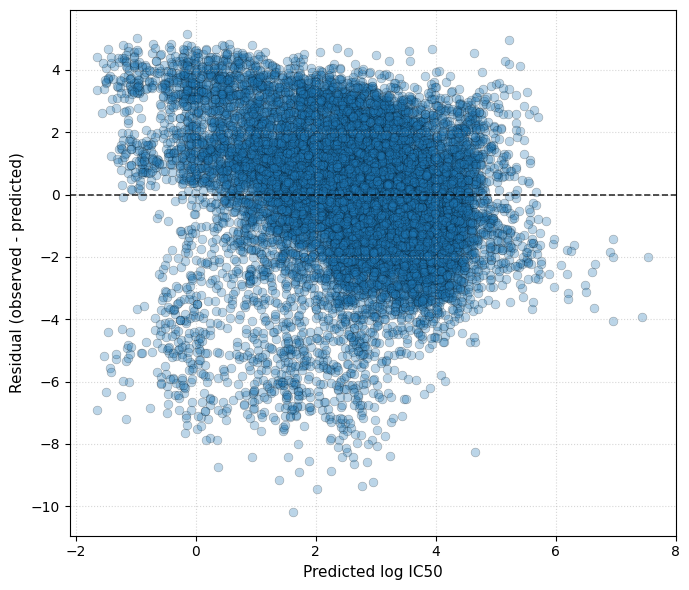

In [39]:
residuals = y_test_orig - test_preds_orig
rmse_val = root_mean_squared_error(y_test_orig, test_preds_orig)
r2_val = r2_score(y_test_orig, test_preds_orig)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(test_preds_orig, residuals, color='#1f77b4', alpha=0.3, s=40, edgecolors='black', linewidth=0.4, marker = 'o')
ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)

ax.set_xlabel("Predicted log IC50", fontsize=11)
ax.set_ylabel("Residual (observed - predicted)", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)

#info_text = (
#    f"RMSE: {rmse_val:.3f}\n"
#    f"R²: {r2_val:.3f}\n"
#)
#ax.text(0.02, 0.95, info_text, transform=ax.transAxes, fontsize=8,
#        verticalalignment='top',
#        bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc'))

plt.tight_layout()
#plt.savefig("residuals_vs_predicted.png", bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

check_df = pd.DataFrame({
    'drug_id': drug_groups[idx_test],
    'y_true': y_test_orig,
    'y_pred': test_preds_orig,
    'residual': y_test_orig - test_preds_orig
})

# Calculate the mean residual per active ingredient
drug_summary = check_df.groupby('drug_id').agg(
    n_samples=('residual', 'count'),
    mean_residual=('residual', 'mean'),
    mean_true=('y_true', 'mean'),
    mean_pred=('y_pred', 'mean')
).sort_values('mean_residual')

print("Top 5 active ingredients with the most harmful residues:")
print(drug_summary.head(5))

You can see that these outliers in residuals plot stem mainly from two/three drugs (in average)

In [ ]:
extreme_drug_ids = ["1911", "1248", "1372"]
outlier_names = df[df['DRUG_ID'].isin(extreme_drug_ids)][['DRUG_ID', 'DRUG_NAME']].drop_duplicates()
print(outlier_names)

In [40]:
#import matplotlib.pyplot as plt
import seaborn as sns
import torch

def plot_attention_weights(model, test_loader, device, sample_idx=0):
    # 1. Ein Batch aus dem PyG-Dataloader laden
    # PyG gibt nur noch ein einziges Batch-Objekt zurück!
    batch = next(iter(test_loader))
    batch = batch.to(device)

    # 2. Forward-Pass durchführen (Evaluationsmodus)
    model.eval()
    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda"): # Mixed Precision beibehalten
            # Dem Modell das Gen-Profil und den gesamten Graphen übergeben
            _ = model(batch.gene, batch, save_attention=True)

    # 3. Attention Weights aus dem Modell extrahieren
    if model.last_attn_weights is None:
        print("Error: Attention weights were not saved.")
        return

    attn_dict = model.last_attn_weights
    gene_to_drug_attn = attn_dict["gene_to_drug"][sample_idx]
    drug_to_gene_attn = attn_dict["drug_to_gene"][sample_idx]

    # 4. Heatmaps generieren
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Gene-to-Drug
    sns.heatmap(gene_to_drug_attn, annot=False, cmap="Blues", ax=axes[0])
    axes[0].set_title(f"Gene-to-Drug Attention (Sample {sample_idx})")
    # Die X-Achse zeigt jetzt ECHTE ATOME statt abstrakter Fingerprint-Cluster!
    axes[0].set_xlabel("Drug Tokens (Atoms in the Molecule)")
    axes[0].set_ylabel("Gene Tokens (Queries)")

    # Drug-to-Gene
    sns.heatmap(drug_to_gene_attn, annot=False, cmap="Oranges", ax=axes[1])
    axes[1].set_title(f"Drug-to-Gene Attention (Sample {sample_idx})")
    axes[1].set_xlabel("Gene Tokens (Keys)")
    axes[1].set_ylabel("Active Ingredient Tokens (Queries – Atoms in the Molecule)")

    plt.tight_layout()
    plt.show()

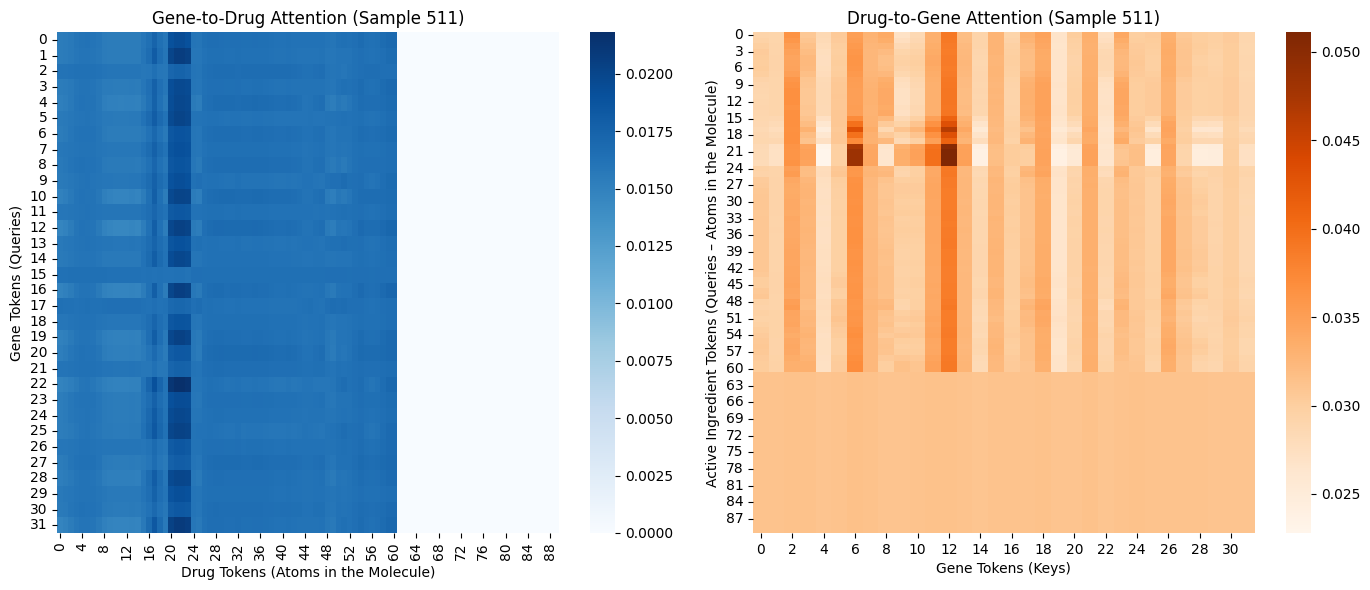

In [41]:
plot_attention_weights(model, test_loader, device, sample_idx=511)

In [ ]:
from rdkit.Chem import Draw

# Reload the PyG batch object to check the SMILES strings and names
batch = next(iter(test_loader))

num_real_atoms = batch.ptr[512] - batch.ptr[511]
print(f"The molecule in Sample 0 has exactly {num_real_atoms.item()} atoms.")

smiles_of_sample_0 = smiles_raw[idx_test][511]
mol = Chem.MolFromSmiles(smiles_of_sample_0)
print(f"SMILES: {smiles_of_sample_0}")

img = Draw.MolToImage(mol)
display(img)

Visualizing Attention for SMILES: CCC1=CC(=C(C=C1N2CCC(CC2)N3CCN(CC3)S(=O)(=O)C)OC)NC4=NC=CC(=N4)C5=C(N=C6N5C=CC=C6)C7=CC(=C(C=C7)OC)C(=O)NC8=C(C=CC=C8F)F
Number of atoms: 61


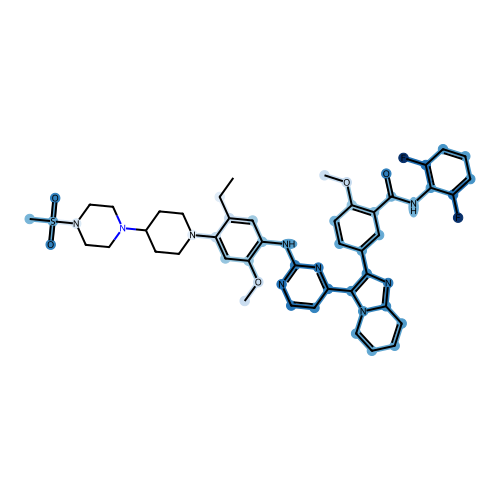

In [ ]:
import numpy as np
import matplotlib
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display

def visualize_atom_attention(mol_smiles, gene_to_drug_attn, num_real_atoms):
    """
    Overlays cross-attention weights onto the 2D chemical structure of a molecule.
    """
    # Create RDKit molecule and compute 2D coordinates for drawing
    mol = Chem.MolFromSmiles(mol_smiles)
    if mol is None:
        print("Invalid SMILES string.")
        return
    rdDepictor.Compute2DCoords(mol)

    # Aggregate attention weights for the atoms
    # gene_to_drug_attn shape is (Num_Gene_Tokens, Max_Atoms_in_Batch)
    # We average across all gene tokens (axis=0) to get the global importance of each atom
    atom_attention = gene_to_drug_attn.mean(axis=0)

    # Slice the array to remove padding (keep only the real atoms of this specific molecule)
    real_atom_attention = atom_attention[:num_real_atoms]

    # Normalize the attention weights to a range of [0, 1] for coloring
    min_val = real_atom_attention.min()
    max_val = real_atom_attention.max()
    if max_val > min_val:
        normalized_attn = (real_atom_attention - min_val) / (max_val - min_val)
    else:
        normalized_attn = np.zeros_like(real_atom_attention)

    # Map normalized weights to colors using matplotlib's 'Blues' colormap
    cmap = matplotlib.colormaps.get_cmap('Blues')
    highlight_atoms = []
    highlight_colors = {}

    # We only highlight atoms that have at least 10% relative importance to keep the plot clean
    importance_threshold = 0.10

    for atom_idx, weight in enumerate(normalized_attn):
        if weight > importance_threshold:
            highlight_atoms.append(atom_idx)
            # cmap returns an RGBA tuple, but RDKit expects RGB tuples (R, G, B) between 0 and 1
            rgba = cmap(weight)
            highlight_colors[atom_idx] = tuple(rgba[:3])

    # Draw the molecule with RDKit
    # Increase the canvas size for better resolution
    drawer = rdMolDraw2D.MolDraw2DSVG(500, 500)

    # Optional: Customize drawing options (e.g., continuous drawing, no atom indices)
    opts = drawer.drawOptions()
    opts.clearBackground = False

    drawer.DrawMolecule(
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=highlight_colors
    )
    drawer.FinishDrawing()

    # Display the SVG image directly in the Jupyter Notebook
    svg_text = drawer.GetDrawingText()
    display(SVG(svg_text))

# ==========================================
# Execution using the data from Sample X
# ==========================================
# We fetch the first batch from the test_loader to get the actual number of atoms
sample = 512
batch = next(iter(test_loader))
num_real_atoms_sample = (batch.ptr[sample] - batch.ptr[sample-1]).item()
smiles_sample = smiles_raw[idx_test][sample-1]

# Retrieve attention weights directly from the model (for the sample)
attn_dict = model.last_attn_weights
gene_to_drug_attn = attn_dict["gene_to_drug"][sample-1]

print(f"Visualizing Attention for SMILES: {smiles_sample}")
print(f"Number of atoms: {num_real_atoms_sample}")

visualize_atom_attention(smiles_sample, gene_to_drug_attn, num_real_atoms_sample)

Gene-to-drug:
- Attention hardly varies among the different gene tokens (rows), but instead exhibits a vertical striped pattern.
- seems like the model always prioritizes the same chemical features, regardless of the genomic profile.

Drug-to-gene:
- focus on token 1 and 3
- The values fall within a very narrow range between 0.1 and 0.15, and are thus close to the uniform distribution of 0.125

Samples analyzed in the test set: 14581
Moderate correlation between samples: 0.7027
Number of gene tokens: 29
Maximum standard deviation (gene-to-drug): 0.0218


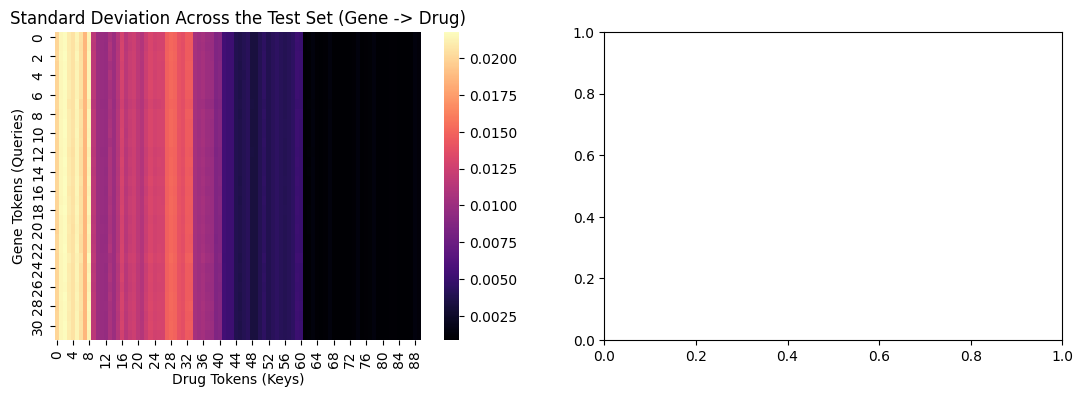

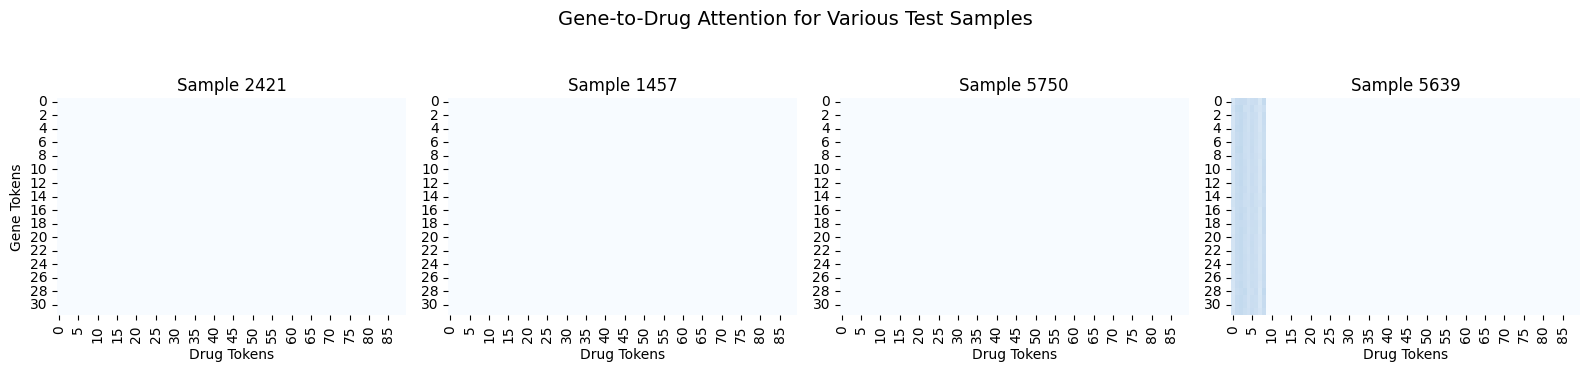

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

def evaluate_attention_diversity(model, test_loader, device, num_samples_to_plot=4):
    model.eval()
    all_gene_to_drug = []
    #all_drug_to_gene = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)

            with torch.amp.autocast(device_type="cuda"):
                _ = model(batch.gene, batch, save_attention=True)
            all_gene_to_drug.append(model.last_attn_weights["gene_to_drug"])
            #all_drug_to_gene.append(model.last_attn_weights["drug_to_gene"])

    # Shape: (N_total_samples, Num_Query_Tokens, Num_Key_Tokens)
    g2d = np.concatenate(all_gene_to_drug, axis=0)
    #d2g = np.concatenate(all_drug_to_gene, axis=0)

    print(f"Samples analyzed in the test set: {len(g2d)}")

    # 2. Statistische Auswertung: Standardabweichung über alle Samples
    std_g2d = np.std(g2d, axis=0)
    #std_d2g = np.std(d2g, axis=0)

    # Calculate pairwise correlations between different samples
    # Flat vectors per sample for Gene-to-Drug:
    flat_g2d = g2d.reshape(len(g2d), -1)
    sample_corr = np.corrcoef(flat_g2d[:100]) # Erste 100 Samples
    avg_corr = np.mean(sample_corr[np.triu_indices_from(sample_corr, k=1)])

    print(f"Moderate correlation between samples: {avg_corr:.4f}")
    print(f"Number of gene tokens: {len(all_gene_to_drug)}")
    #print(f"Number of drug tokens: {len(all_drug_to_gene)}")
    print(f"Maximum standard deviation (gene-to-drug): {std_g2d.max():.4f}")
    #print(f"Maximum standard deviation (drug-to-gene): {std_d2g.max():.4f}")

    # Variance Heat Map (Where exactly are changes occurring?)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.heatmap(std_g2d, annot=False, fmt=".3f", cmap="magma", ax=axes[0])
    axes[0].set_title("Standard Deviation Across the Test Set (Gene -> Drug)")
    axes[0].set_xlabel("Drug Tokens (Keys)")
    axes[0].set_ylabel("Gene Tokens (Queries)")

    #sns.heatmap(std_d2g, annot=False, fmt=".3f", cmap="magma", ax=axes[1])
    #axes[1].set_title("Standard Deviation Across the Test Set (Drug -> Gene)")
    #axes[1].set_xlabel("Gene Tokens (Keys)")
    #axes[1].set_ylabel("Drug Tokens (Queries)")
    #plt.tight_layout()
    #plt.show()

    # 4. Direct visual comparison of N random examples (gene-to-drug)
    fig, axes = plt.subplots(1, num_samples_to_plot, figsize=(4 * num_samples_to_plot, 3.5))
    indices = np.random.choice(len(g2d), size=num_samples_to_plot, replace=False)

    for i, idx in enumerate(indices):
        sns.heatmap(g2d[idx], annot=False, cmap="Blues", ax=axes[i], cbar=False, vmin=0.08, vmax=0.22)
        axes[i].set_title(f"Sample {idx}")
        axes[i].set_xlabel("Drug Tokens")
        if i == 0:
            axes[i].set_ylabel("Gene Tokens")

    plt.suptitle("Gene-to-Drug Attention for Various Test Samples", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

# Aufruf
evaluate_attention_diversity(model, test_loader, device)

-> attention collapse would mean correlation~1 and standard deviation~0 \
so no attention collapse \
drug-to-gene shows homogeneity, means model couldn't use drug for more information about genes

## Overlap between drugs with structural similarity (global) and functional groups (local)

A. 2D Density & Correlation Analysis (Scatter / Hexbin Plot): Plot $S_{\text{struct}}$ on the X-axis and $S_{\text{FG}}$ on the Y-axis for all active ingredient pairs. Since there are $N \times (N-1) / 2$ pairs, use a hexbin or KDE plot: Calculate the Spearman rank correlation $r_s$ between the two matrices (or perform a Mantel test).

B. Quadrant Analysis (Identification of Scaffold Hops) Set thresholds (e.g., $S_{\text{struct}} \ge 0{,}5$ and $S_{\text{FG}} \ge 0{,}7$) and divide the pairs into four quadrants: High Structure + High FG: Classic chemical analogs/series. Low Structure + High FG (Scaffold Hops): Compounds with completely different scaffolds but identical functional groups. Particularly biologically relevant for your master’s thesis, as they often bind to similar targets. High Structure + Low FG: Structurally related molecules in which key groups have been substituted (potential activity cliffs).

C. $k$-NN Jaccard Overlap (Local Neighborhoods) Determine the top $k$ most similar partners for each molecule based on structure ($N_{\text{struct}}^{(k)}$) and based on functional groups ($N_{\text{FG}}^{(k)}$). $$\text{Overlap}(m) = \frac{\vert{}N_{\text{struct}}^{(k)}(m) \cap N_{\text{FG}}^{(k)}(m)\vert{}}{\vert{}N_{\text{struct}}^{(k)} (m) \cup N_{\text{FG}}^{(k)}(m)\vert{}}$$A low average overlap indicates that functional groups span different similarity spaces than 2D fingerprints.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Fragments

# Load SMILES and unique molecules
unique_drugs = df.drop_duplicates(subset=['DRUG_ID']).copy()
smiles_list = unique_drugs['SMILES'].tolist()
mols = [Chem.MolFromSmiles(s) for s in smiles_list]

# Calculate structural similarity (Morgan Fingerprints -> Tanimoto)
fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=1024) for m in mols]
n_mols = len(mols)

struct_sim_matrix = np.zeros((n_mols, n_mols))
for i in range(n_mols):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    struct_sim_matrix[i] = sims

# Calculate the similarity of functional groups (Jaccard on RDKit fragments)
frag_funcs = [func for name, func in Fragments.__dict__.items() if name.startswith('fr_')]
frag_counts = np.array([[func(m) > 0 for func in frag_funcs] for m in mols], dtype=bool)

# Jaccard Distance (1 – Jaccard Similarity)
fg_dist_matrix = squareform(pdist(frag_counts, metric='jaccard'))
fg_sim_matrix = 1.0 - fg_dist_matrix
np.fill_diagonal(fg_sim_matrix, 1.0)

# Extract the upper triangular matrix (only unique pairs where i < j)
triu_idx = np.triu_indices(n_mols, k=1)
s_struct = struct_sim_matrix[triu_idx]
s_fg = fg_sim_matrix[triu_idx]

# Calculate Correlation
corr, p_val = spearmanr(s_struct, s_fg)
print(f"Spearman Correlation: {corr:.4f} (p = {p_val:.2e})")

# Visualization & Quadrant Analysis
plt.figure(figsize=(8, 6))
hb = plt.hexbin(s_struct, s_fg, gridsize=40, cmap='viridis', mincnt=1, bins='log')
plt.colorbar(hb, label='Log10(Number of pairs)')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7)
plt.axhline(y=0.7, color='red', linestyle='--', alpha=0.7)

plt.xlabel("Global Structural Similarity (Morgan Tanimoto)")
plt.ylabel("Functional Group Similarity (Jaccard)")
plt.title(f"Structural- vs. FG-Similarity (Spearman r = {corr:.2f})")
plt.tight_layout()
plt.show()

# Filter scaffold hops (low structural similarity but identical functional groups)
scaffold_hops = np.where((s_struct < 0.3) & (s_fg > 0.8))[0]
print(f"Scaffold-hop candidate pairs found: {len(scaffold_hops)}")

In [ ]:
from rdkit.Chem import Draw

# Resolve the indices of the scaffold-hop pairs
hop_pairs = [(triu_idx[0][i], triu_idx[1][i]) for i in scaffold_hops]

# Show the Top 3 Couples
display_mols = []
legends = []

for idx1, idx2 in hop_pairs[:3]:
    d1 = unique_drugs.iloc[idx1]
    d2 = unique_drugs.iloc[idx2]

    display_mols.extend([mols[idx1], mols[idx2]])
    legends.extend([
        f"{d1['DRUG_NAME']} (ID:{d1['DRUG_ID']})",
        f"{d2['DRUG_NAME']} (ID:{d2['DRUG_ID']})"
    ])

#img =
Draw.MolsToGridImage(display_mols, molsPerRow=2, subImgSize=(300, 200), legends=legends)
#img.save("scaffold_hops_examples.png")